# NER Matching — Exploration

Explore `data/results.parquet` produced by `run_match.py`.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

full_results = pd.read_parquet('data/results.parquet')
delegates = pd.read_parquet('data/delegates_reference.parquet')

print(f'Full results: {len(full_results):,} rows')
print(f'Columns: {full_results.columns.tolist()}')
full_results.head(5)

Full results: 1,938,329 rows
Columns: ['span_idx', 'tag_text', 'year', 'cand_1', 'score_1', 'cand_2', 'score_2', 'cand_3', 'score_3', 'cand_4', 'score_4', 'cand_5', 'score_5', 'raw_tag_text', 'resolution_id', 'paragraph_id']


,span_idx,tag_text,year,cand_1,score_1,cand_2,score_2,cand_3,score_3,cand_4,score_4,cand_5,score_5,raw_tag_text,resolution_id,paragraph_id
0,0,vanden honert,1705,13355,0.8372,21962,0.1900,17038,0.1573,21097,0.1453,13449,0.1308,"Vanden Honert, Heemskerck, Meerens, Raedt - Be...",session-3760-num-1-attendance_list,session-3760-num-1-para-9
1,1,heemskerck,1705,14192,0.4572,20062,0.1687,14224,0.1436,17388,0.1419,13959,0.1393,"Vanden Honert, Heemskerck, Meerens, Raedt - Be...",session-3760-num-1-attendance_list,session-3760-num-1-para-9
2,2,meerens,1705,13729,0.3983,460,0.2337,19651,0.1614,16296,0.1583,republic_add_10,0.1251,"Vanden Honert, Heemskerck, Meerens, Raedt - Be...",session-3760-num-1-attendance_list,session-3760-num-1-para-9
3,3,raedt - becker,1705,13961,0.6697,16879,0.6569,19967,0.1339,17388,0.1326,None,0.0000,"Vanden Honert, Heemskerck, Meerens, Raedt - Be...",session-3760-num-1-attendance_list,session-3760-num-1-para-9
4,4,met een extraordinaris gedeputeerde uyt wellandt,1705,3062,0.1493,19717,0.1412,17429,0.1364,14026,0.1362,18009,0.1204,"Vanden Honert, Heemskerck, Meerens, Raedt - Be...",session-3760-num-1-attendance_list,session-3760-num-1-para-9


In [2]:
delegates

,cons_id_str,fullname,voornaam,tussenvoegsel,geslachtsnaam,heerlijkheid,provincie,geboortejaar,overlijdensjaar,minjaar,maxjaar,pattern
0,18744,"Abbink, Bernard Engelbert",Bernard Engelbert,None,Abbink,None,None,NaN,NaN,1757.0,1792.0,abbink
1,18379,"Ablaing, Johan Daniël d'",Johan Daniël,d',Ablaing,"Giessenburg en Haulchin, Peursum, Moersbergen,...",Utrecht,1703.0,1775.0,1747.0,1775.0,ablaing;d' ablaing
2,13591,"Acquet, Hendrik Georgesz. d'",Hendrik Georgesz.,d',Acquet,None,Holland,1692.0,1769.0,1732.0,1769.0,acquet;d' acquet
3,17205,"Alberda, Onno Reint",Onno Reint,None,Alberda,Ekenstein,Groningen,1752.0,1821.0,1782.0,1794.0,alberda
4,20319,"Alberda, Onno Tamminga",Onno Tamminga,None,Alberda,Rensuma,Groningen,1754.0,1829.0,1782.0,1795.0,alberda
...,...,...,...,...,...,...,...,...,...,...,...,...
1022,republic_add_011,"Veth, Jacob",Jacob,None,veth,None,Zeeland,NaN,1667.0,NaN,NaN,veth
1023,republic_add_012,"Veth, Jacob",Jacob,None,veth,None,Zeeland,NaN,1667.0,NaN,NaN,veth
1024,republic_add_16,"Welderen, Bernhard vanUbbergen",Bernhard,van,welderen,Ubbergen,Gelderland,1700.0,1770.0,1723.0,1770.0,van welderen;welderen
1025,republic_add_13,"Quint, Cornelis Heemstede",Cornelis,None,quint,Heemstede,Utrecht,1666.0,1743.0,1694.0,1743.0,quint


In [3]:
full_results.score_1.value_counts(bins=10, sort=False)


(-0.002, 0.1]     12920
(0.1, 0.2]       525942
(0.2, 0.3]       609437
(0.3, 0.4]       153469
(0.4, 0.5]        61913
(0.5, 0.6]        83643
(0.6, 0.7]        71700
(0.7, 0.8]       127758
(0.8, 0.9]       123903
(0.9, 1.0]       167644
Name: count, dtype: int64

In [4]:
full_results[full_results.score_1.between(0.5, 0.7)].sample(10)

,span_idx,tag_text,year,cand_1,score_1,cand_2,score_2,cand_3,score_3,cand_4,score_4,cand_5,score_5,raw_tag_text,resolution_id,paragraph_id
1922988,11129,heeren van heeckeren tot enghuisen,1795,19897,0.6847,19874,0.6847,17333,0.6847,17500,0.6847,17328,0.6247,"Heeren van Heeckeren tot Enghuisen, Lestevenen...",session-4795-num-23-attendance_list,session-4795-num-23-para-1
612048,68074,pelt. van hoorn. van nassau-zeyst,1735,16120,0.5093,16054,0.5093,15097,0.3923,17253,0.3414,17233,0.3220,"Heeren van Lynden, van Welderen, van Singendon...",session-3790-num-78-attendance_list,session-3790-num-78-para-1
539545,79278,nassau-siegen,1730,17233,0.5277,18511,0.1452,20366,0.1452,None,0.0000,None,0.0000,Nassau-Siegen,session-3785-num-53-resolution-8,session-3785-num-53-para-12
500718,40451,grave van visconti,1727,17247,0.6080,13551,0.1436,385,0.1223,14430,0.1124,142,0.1101,Grave van Visconti,session-3782-num-252-resolution-10,session-3782-num-252-para-13
1750006,40373,missive vander meer,1734,13346,0.6843,20767,0.2048,460,0.1774,15098,0.1714,13641,0.1262,Missive vander Meer,session-4675-num-8-resolution-3,session-4675-num-8-para-5
490693,30426,van voorst. vegilin. van haarsolte,1727,18410,0.6097,16193,0.3362,302,0.2921,17396,0.2361,16232,0.1984,"Heeren Van Lynden, van Welderen, van Heuckelom...",session-3782-num-44-attendance_list,session-3782-num-44-para-1
19922,19922,. lycklama,1705,21773,0.6314,17575,0.1113,451,0.1009,None,0.0000,None,0.0000,". Lycklama, du Tour. Niland, Roelinck. Wichers.",session-3760-num-209-attendance_list,session-3760-num-209-para-10
772710,50432,met een extraordinaris gedeputeerde uyt de pro...,1745,17165,0.6417,17872,0.6417,3062,0.1340,14003,0.1178,16279,0.1094,"Heeren van Heeckeren tot den Brantzenborgh, Co...",session-3800-num-214-attendance_list,session-3800-num-214-para-1
163239,32350,broeckhuysen,1710,16186,0.5633,20351,0.2294,20240,0.2237,15933,0.1949,37,0.1218,Broeckhuysen,session-3765-num-200-attendance_list,session-3765-num-200-para-5
863159,44920,van hoorn. van utenhoven tot bottestein. van i...,1750,17241,0.5309,13111,0.4473,21795,0.4473,20176,0.4342,16120,0.4342,"Heeren Verschoor, van Heeckeren tot den Brantz...",session-3805-num-313-attendance_list,session-3805-num-313-para-1


In [5]:
full_results.cand_1.value_counts()

cand_1
20384              37854
19949              37681
13386              31387
20710              25742
12369              21070
                   ...  
14076                 10
21817                 10
18843                  9
17336                  7
republic_add_01        6
Name: count, Length: 1020, dtype: int64

## Ad-hoc spot-check

Test arbitrary spans against the delegate reference without needing `results.parquet`.
Edit the `test_spans` list and re-run the cell.

In [6]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))

import pandas as pd
from match import build_store, match_ner
from preprocess import clean_span, extract_title

DELEGATES_PATH = pathlib.Path("data/delegates_reference.parquet")
TOP_K = 5
YEAR_TOLERANCE = 15

delegates = pd.read_parquet(DELEGATES_PATH)
store = build_store(delegates)
id_to_name = delegates.set_index("cons_id_str")["fullname"].to_dict()

# --- edit these spans to spot-check ---
test_spans = [
    ("vanden honert",       1705),
    ("Heinsius",          1710),
    ("grave van Rechteren", 1720),
    ("raedt - becker", 1615),
    ("Slingelandt",       1730),
]

rows = [{"tag_text": clean_span(s), "year": y, "raw": s, "title": extract_title(s)}
        for s, y in test_spans]
ner_df = pd.DataFrame(rows)

results = match_ner(store, ner_df[["tag_text", "year"]], top_k=TOP_K,
                    year_tolerance=YEAR_TOLERANCE)

# Resolve candidate IDs to full names
for k in range(1, TOP_K + 1):
    col = f"cand_{k}"
    if col in results.columns:
        results[f"name_{k}"] = results[col].map(
            lambda x: id_to_name.get(str(x), "") if pd.notna(x) else ""
        )

results.insert(1, "raw", [r["raw"] for r in rows])
results.insert(2, "title", [r["title"] for r in rows])

display_cols = (["raw", "title", "year", "score_1", "name_1"]
                + [c for k in range(2, TOP_K + 1)
                   for c in (f"score_{k}", f"name_{k}") if f"score_{k}" in results.columns])
results[display_cols]

,raw,title,year,score_1,name_1,score_2,name_2,score_3,name_3,score_4,name_4,score_5,name_5
0,vanden honert,,1705,0.8372,"Honert, Cornelis van den",0.1900,"Boner, Eco Evertsz.",0.1573,"Brande, Johan Pieter van den",0.1453,"Lynden, Reinhard van",0.1308,"Brandeler, Johan Françoisz. van den"
1,Heinsius,,1710,1.0000,"Heinsius, Anthonie",0.1595,"Heim, Anthonie van der",0.1061,"Essenius, Leonard",0.1061,"Essenius, Samuel",0.1026,"Bothenius, Louis"
2,grave van Rechteren,grave,1720,0.7049,"Rechteren tot Rechteren, Joachim Hendrik Adolf...",0.5338,"Rechteren tot Gramsbergen, Reinhard Burchard R...",0.1737,"Staveren, Thomas van",0.1729,"Heteren, Leonard van",0.1629,"Duyn van 's-Gravenmoer, Adam Adriaan van der"
3,raedt - becker,,1615,0.1979,"Backer, Jacob",0.1059,"Hoeckelom, Willem van",0.0000,,0.0000,,0.0000,
4,Slingelandt,,1730,0.9221,"Slingelandt, Simon van",0.2098,"Bijlandt, Otto Frederik Roeleman van den",0.1710,"Goslinga, Sicco van",0.1601,"Gendt, Willem Joseph van",0.1466,"Roelands, Roeland Albert"


## Score distribution

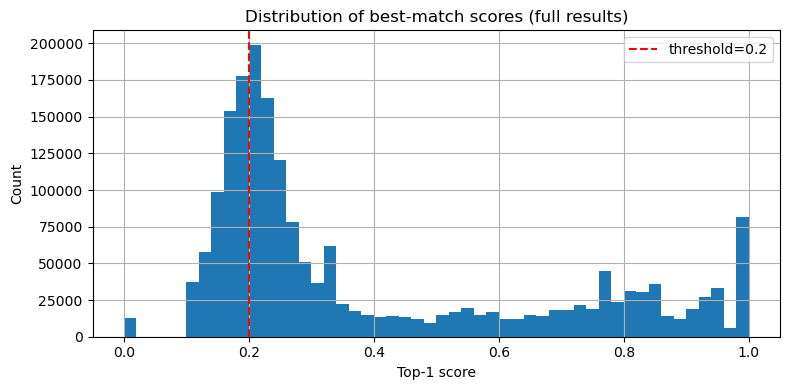

count    1.938329e+06
mean     3.957261e-01
std      2.783542e-01
min      0.000000e+00
25%      1.938000e-01
50%      2.494000e-01
75%      6.108000e-01
max      1.000000e+00
Name: score_1, dtype: float64

Match rate (score_1 >= 0.2): 72.3%


In [7]:
THRESHOLD = 0.2

fig, ax = plt.subplots(figsize=(8, 4))
full_results['score_1'].hist(bins=50, ax=ax, edgecolor='none')
ax.axvline(THRESHOLD, color='red', linestyle='--', label=f'threshold={THRESHOLD}')
ax.set_xlabel('Top-1 score')
ax.set_ylabel('Count')
ax.set_title('Distribution of best-match scores (full results)')
ax.legend()
plt.tight_layout()
plt.show()

print(full_results['score_1'].describe())
print(f"\nMatch rate (score_1 >= {THRESHOLD}): {(full_results['score_1'] >= THRESHOLD).mean():.1%}")


## Match rate by year

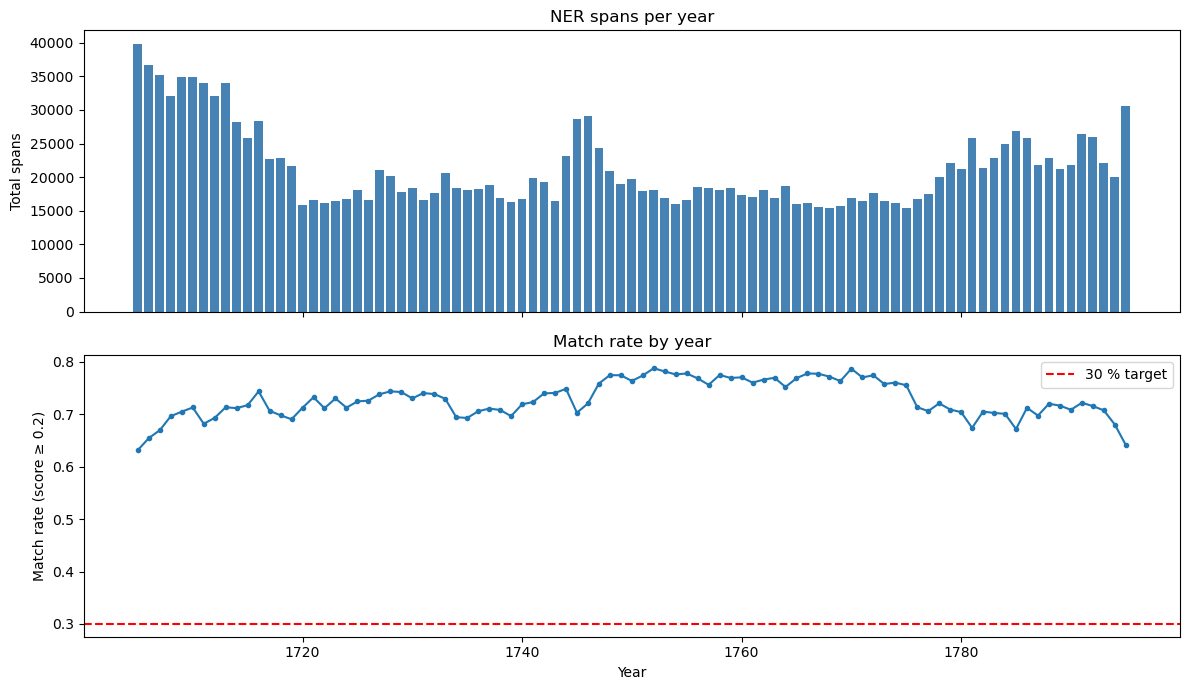

,year,total,matched,match_rate
0,1705,39848,25178,0.631851
90,1795,30651,19664,0.641545
1,1706,36658,23998,0.654646
2,1707,35251,23608,0.669711
80,1785,26896,18070,0.671847
76,1781,25767,17372,0.674196
89,1794,20087,13669,0.680490
6,1711,33966,23163,0.681947
14,1719,21589,14908,0.690537
30,1735,18078,12528,0.692997


In [8]:
by_year = (
    full_results.groupby('year')
    .agg(
        total=('score_1', 'count'),
        matched=('score_1', lambda x: (x >= THRESHOLD).sum()),
    )
    .assign(match_rate=lambda d: d['matched'] / d['total'])
    .reset_index()
)

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].bar(by_year['year'], by_year['total'], width=0.8, color='steelblue')
axes[0].set_ylabel('Total spans')
axes[0].set_title('NER spans per year')

axes[1].plot(by_year['year'], by_year['match_rate'], marker='o', markersize=3)
axes[1].axhline(0.3, color='red', linestyle='--', label='30 % target')
axes[1].set_ylabel(f'Match rate (score ≥ {THRESHOLD})')
axes[1].set_xlabel('Year')
axes[1].set_title('Match rate by year')
axes[1].legend()

plt.tight_layout()
plt.show()

by_year.sort_values('match_rate').head(10)  # worst years


## Top unmatched spans

Spans with score_1 < 0.1 — candidates for new delegates or noise.

In [9]:
unmatched = full_results[full_results['score_1'] < 0.1].copy()
print(f'Unmatched spans: {len(unmatched):,} ({len(unmatched)/len(full_results):.1%})')

top_unmatched = (
    unmatched.groupby('tag_text')
    .agg(count=('year', 'count'), years=('year', lambda x: sorted(x.unique())))
    .reset_index()
    .sort_values('count', ascending=False)
    .head(50)
)
top_unmatched

Unmatched spans: 12,900 (0.7%)


,tag_text,count,years
5,',1480,"[1706, 1709, 1710, 1711, 1712, 1713, 1714, 171..."
2556,l,1457,"[1706, 1709, 1710, 1711, 1712, 1713, 1714, 171..."
762,calkoen,500,"[1726, 1727, 1728, 1729, 1731, 1732, 1733, 173..."
2934,missive calkoen,331,"[1726, 1727, 1730, 1731, 1732, 1733, 1734, 173..."
2460,junior,320,"[1707, 1751, 1752, 1753, 1754, 1755, 1756, 175..."
1,&c,108,"[1705, 1706, 1707, 1708, 1709, 1710, 1711, 171..."
756,cadogan,104,"[1705, 1707, 1708, 1709, 1714, 1715, 1716, 171..."
1678,griffier,89,"[1705, 1706, 1707, 1708, 1709, 1710, 1711, 171..."
1897,hirzel,79,"[1709, 1726, 1729, 1730, 1737, 1738, 1740, 174..."
3388,prins carel,74,"[1705, 1706, 1707, 1722, 1729, 1744, 1745, 174..."


## Sample: span + top-3 candidates

In [14]:
id_to_name = delegates.set_index('cons_id_str')['fullname'].to_dict()

filtered = full_results[full_results['score_1'] >= THRESHOLD]
print(f'Filtered results: {len(filtered):,} rows (score_1 >= {THRESHOLD})')
n = min(20, len(filtered))

if n == 0:
    print('No rows pass the current threshold.')
    sample = filtered.copy()
else:
    sample = filtered.sample(n, random_state=42).copy()

for k in range(1, 4):
    col = f'cand_{k}'
    if col in sample.columns:
        sample[f'name_{k}'] = sample[col].map(lambda x: id_to_name.get(str(x), '') if pd.notna(x) else '')

display_cols = ['raw_tag_text', 'tag_text', 'year', 'score_1', 'name_1', 'score_2', 'name_2', 'score_3', 'name_3']
sample[[c for c in display_cols if c in sample.columns]].sort_values('score_1', ascending=False)


Filtered results: 1,400,624 rows (score_1 >= 0.2)


,raw_tag_text,tag_text,year,score_1,name_1,score_2,name_2,score_3,name_3
801803,"Heeren van Randwyck, van Welderen, van Benthem...",hop,1747,1.0000,"Hop, Jacob",0.2488,"Hoop, Cornelis Gijsbertsz. van der",0.0000,
1125887,"Heere Grave Verelst, haar Hoog Mog. extraordin...",heere grave verelst,1768,0.8068,"Verelst, Johan Louis jr.",0.1585,"Staveren, Thomas van",0.1294,"Heeckeren, August Robbert van"
1499781,"Van Riemsdyk, Lithd de Jeude, Teding van Berkh...",w. e. van borssele. van heeckeren van brantsen...,1789,0.7671,"Heeckeren van Brantsenburg, Derk Jan van",0.5013,"Borssele, Willem Zelandus van",0.4827,"Heeckeren, Ludolph van"
950941,"Heeren Pieck van Soelen, Tengnagel, van Welder...",heeren pieck van soelen,1756,0.7522,"Pieck, Hendrik",0.7522,"Pieck, Karel",0.7522,"Pieck, Willem Hendrik"
1720993,missive vander Meer,missive vander meer,1725,0.6843,"Meer, Jacob van der",0.2048,"Mandere, Jacob van der",0.1774,"Meerveld, Jan Hendrikse van"
1494459,"Van Wassenaer Catwyk, van Wassenaer Starrenbur...",met een extraordinaris gedeputeerde uit de pro...,1789,0.5940,"Scheltinga, Martinus van",0.5940,"Scheltinga, Martinus van",0.1395,"Rechteren, Johan van"
252526,"Heeren van Welderen, van Oldersom, van Essen, ...",ham. van sterrenaurgh,1713,0.5566,"Ham, Jan",0.1843,"Bergh, Johan van den",0.1843,"Bergh, Christoffel van den"
1788199,"Heeren Torck, Bentinck, van Groenendijck, Bute...",van groenendijck,1745,0.5307,"Groenendijk, Adriaan van",0.2581,"Groenewegen van der Made, Dirk Simonsz.",0.2510,"Loenen, Johannes Bernardus van"
519003,"Heeren Van Welderen, van Singendonek, Coulman,...",spieringh.,1728,0.5093,"Spiering, Cornelis Willemsz.",0.2388,"Weveringh, Adriaen Adriaensz.",0.2011,"Heringa, None"
1247382,Heere van Slingeland,heere van slingeland,1776,0.4666,"Slingelandt, Barthout van",0.1860,"Heeckeren, Evert Christiaan Carel Wilhelm van",0.1860,"Heeckeren, Frans Jan van"


In [11]:
len(full_results), (full_results['score_1'] >= THRESHOLD).sum()


(1938329, np.int64(1400624))

In [12]:
full_results['score_1'].value_counts(bins=10, sort=False).sort_index()


(-0.002, 0.1]     12920
(0.1, 0.2]       525942
(0.2, 0.3]       609437
(0.3, 0.4]       153469
(0.4, 0.5]        61913
(0.5, 0.6]        83643
(0.6, 0.7]        71700
(0.7, 0.8]       127758
(0.8, 0.9]       123903
(0.9, 1.0]       167644
Name: count, dtype: int64

In [13]:
full_results[full_results['score_1'].between(0.5, 0.7)].sample(min(10, len(full_results)))


,span_idx,tag_text,year,cand_1,score_1,cand_2,score_2,cand_3,score_3,cand_4,score_4,cand_5,score_5,raw_tag_text,resolution_id,paragraph_id
307746,16834,heeren van broeckhuysen,1716,16186,0.5232,20351,0.2308,17322,0.2282,20281,0.2282,18507,0.2282,Heeren van Broeckhuysen,session-3771-num-45-resolution-5,session-3771-num-45-para-7
578882,34908,lewe van aduardt.,1733,17540,0.5783,19681,0.5783,20424,0.5783,17175,0.1096,None,0.0000,"Heeren van Lynden, van Welderen, van Heeckeren...",session-3788-num-14-attendance_list,session-3788-num-14-para-1
387486,12690,heere taats van amerongen,1720,18255,0.6574,17461,0.6307,14757,0.2036,483,0.1522,466,0.1337,Heere Taats van Amerongen,session-3775-num-71-attendance_list,session-3775-num-71-para-1
1435704,53504,pesters. van haersma,1786,21212,0.6935,13131,0.6935,19203,0.6305,21742,0.5904,14135,0.5628,"Graswinckel, Noortbergh, Raadpensionaris van B...",session-3846-num-40-attendance_list,session-3846-num-40-para-3
472865,12598,van renswoude,1725,15065,0.6863,19651,0.1994,19777,0.1144,13729,0.1140,17617,0.1106,"Heeren Van Lynden, van Welderen, van Dam, Torc...",session-3780-num-323-attendance_list,session-3780-num-323-para-1
1332677,40215,raadpensionaris van bleiswyk. van lynden van b...,1780,18042,0.6145,19633,0.5849,21097,0.5849,20514,0.5849,17308,0.2727,"Van Boetzelaer, van Slingeland, le Leu de Wilh...",session-3835-num-355-attendance_list,session-3835-num-355-para-1
634410,4583,j. de jongh,1736,15156,0.5624,21027,0.2867,14757,0.2007,17237,0.1474,14000,0.1337,"J. de Jongh, Drossaard van Valckenswaart",session-3791-num-248-resolution-7,session-3791-num-248-para-10
1795930,23277,visconti,1746,17247,0.6993,385,0.1484,None,0.0000,None,0.0000,None,0.0000,"Hoorn, De Milan, Visconti, Van Haren, Tamminga,",session-4699-num-13-attendance_list,session-4699-num-13-para-1
1233453,35677,als vader van desselss minderjaarigen soon fra...,1775,21971,0.5850,20383,0.1337,16287,0.1316,17187,0.1312,16214,0.1271,"Eelko Alta, Predikant in de Gereformeerde Geme...",session-3830-num-116-resolution-9,session-3830-num-116-para-13
1320351,27889,van slingeland,1780,13566,0.5404,483,0.1609,17320,0.1492,17192,0.1478,20997,0.1457,"Heeren van Lynden van Hemmen, van Randwyk, van...",session-3835-num-112-attendance_list,session-3835-num-112-para-1


## Plural HOE marker audit

Focus on spans that include explicit plural/group markers (for example: `heeren`, `gedeputeerden`, `ambassadeurs`, `commissarissen`, `en/ende`, punctuation lists).  
These are strong candidates for multi-person mentions and help quantify where the current matcher underperforms.

In [31]:
import re

# Heuristic plural/group markers that often signal multiple persons in one mention.
PLURAL_HOE_TERMS = [
    "heeren",
    "heren",
    r"de\s+heeren",
    r"de\s+heren",
    "gedeputeerden",
    "gecommitteerden",
    "commissarissen",
    "ambassadeurs",
    "gesanten",
    "raden",
    "burgemeesteren",
    "burgemeesters",
    "bewindhebbers",
    "leden",
]

PLURAL_HOE_PATTERN = re.compile(
    rf"\b(?:{'|'.join(PLURAL_HOE_TERMS)})\b",
    flags=re.IGNORECASE,
)
PLURAL_HOE_EXTRACT_PATTERN = re.compile(
    rf"\b({'|'.join(PLURAL_HOE_TERMS)})\b",
    flags=re.IGNORECASE,
)

CONNECTOR_PATTERN = re.compile(r"\b(?:en|ende|met)\b|[,;/&]", flags=re.IGNORECASE)

plural_audit = full_results.copy()
raw_col = "raw_tag_text" if "raw_tag_text" in plural_audit.columns else "tag_text"
plural_audit["raw_for_audit"] = plural_audit[raw_col].fillna("").astype(str)

plural_audit["has_plural_hoe"] = plural_audit["raw_for_audit"].str.contains(PLURAL_HOE_PATTERN, na=False)
plural_audit["has_connector"] = plural_audit["raw_for_audit"].str.contains(CONNECTOR_PATTERN, na=False)
plural_audit["is_plural_candidate"] = plural_audit["has_plural_hoe"] | plural_audit["has_connector"]

summary = (
    plural_audit.assign(matched=lambda d: d["score_1"] >= THRESHOLD)
    .groupby("is_plural_candidate")
    .agg(
        rows=("score_1", "count"),
        mean_score=("score_1", "mean"),
        median_score=("score_1", "median"),
        match_rate=("matched", "mean"),
    )
    .reset_index()
)

print(f"Threshold: {THRESHOLD}")
print(f"Rows with plural/group signal: {plural_audit['is_plural_candidate'].sum():,} / {len(plural_audit):,}")
summary

Threshold: 0.2
Rows with plural/group signal: 1,255,178 / 1,938,329


,is_plural_candidate,rows,mean_score,median_score,match_rate
0,False,683151,0.320090,0.2223,0.635138
1,True,1255178,0.436892,0.2749,0.770193


In [27]:
# Most frequent plural-marker spans and their performance.
plural_rows = plural_audit[plural_audit["is_plural_candidate"]].copy()

plural_terms = (
    plural_rows["raw_for_audit"]
    .str.extractall(PLURAL_HOE_EXTRACT_PATTERN)[0]
    .str.lower()
    .value_counts()
    .rename_axis("marker")
    .reset_index(name="count")
)

marker_perf = (
    plural_rows.assign(matched=lambda d: d["score_1"] >= THRESHOLD)
    .groupby("has_plural_hoe")
    .agg(
        rows=("score_1", "count"),
        mean_score=("score_1", "mean"),
        match_rate=("matched", "mean"),
    )
    .reset_index()
)

print("Top plural HOE markers:")
display(plural_terms.head(20))

print("\nPerformance split inside plural-candidate set:")
display(marker_perf)

print("\nLow-score plural-candidate examples:")
example_cols = [c for c in ["raw_tag_text", "tag_text", "year", "score_1", "cand_1", "score_2", "cand_2"] if c in plural_rows.columns]
display(
    plural_rows[plural_rows["score_1"] < THRESHOLD]
    .sort_values("score_1")
    .head(40)[example_cols]
)

Top plural HOE markers:


,marker,count
0,heeren,397219
1,gedeputeerden,169152
2,commissarissen,3101
3,ambassadeurs,2196
4,de heeren,1050
5,gecommitteerden,957
6,leden,128
7,raden,118
8,heren,50
9,burgemeesters,46



Performance split inside plural-candidate set:


,has_plural_hoe,rows,mean_score,match_rate
0,False,837762,0.321797,0.671748
1,True,417416,0.667891,0.967773



Low-score plural-candidate examples:


,raw_tag_text,tag_text,year,score_1,cand_1,score_2,cand_2
41454,"Heere Brigadier Blond, na Breda",na breda,1706,0.0,None,0.0,None
204867,"Guillaume Rossel, Koopman tot Bergen",guillaume rossel,1711,0.0,None,0.0,None
1221569,"Peter Symons of Symonds, woonende te Plymouth ...",peter symons of symonds,1774,0.0,None,0.0,None
1701838,"Equ, Heer Graef van Alberoni",equ,1716,0.0,None,0.0,None
1128934,"Rudolphus Bughy, woonende op den Eilande Curacao",rudolphus bughy,1768,0.0,None,0.0,None
19152,"Joseph Arau, Lieutenant van de Granadiers, in ...",joseph arau,1705,0.0,None,0.0,None
1536828,"Casar Valz Boissin, woonende te Amsterdam, als...",casar valz boissin,1791,0.0,None,0.0,None
1047013,"23,, Advocaat voor de respective Hoven van Jus...",23,1762,0.0,None,0.0,None
1409537,"Heeren Van Lynden van Hemmen, van Randwyk, van...",van biljoen,1784,0.0,None,0.0,None
63174,"Koningh van Spaigne, als Hertogh van Gelre",als hertogh van gelre,1707,0.0,None,0.0,None


In [28]:
# Quantify under-splitting: plural/group rows that repeatedly collapse onto one top candidate.
candidate_col = "cand_1"
name_col = "name_1" if "name_1" in plural_rows.columns else None

plural_candidate_rows = plural_rows[plural_rows[candidate_col].notna()].copy()
plural_candidate_rows["matched"] = plural_candidate_rows["score_1"] >= THRESHOLD

collapse_by_raw = (
    plural_candidate_rows.groupby("raw_for_audit")
    .agg(
        rows=(candidate_col, "size"),
        unique_top_candidates=(candidate_col, "nunique"),
        top_candidate=(candidate_col, lambda s: s.mode().iat[0] if not s.mode().empty else None),
        mean_score=("score_1", "mean"),
        matched_rate=("matched", "mean"),
        years=("year", lambda s: sorted(pd.unique(s))[:8]),
    )
    .reset_index()
    .sort_values(["unique_top_candidates", "rows", "mean_score"], ascending=[True, False, False])
)

collapse_by_raw["all_rows_same_top_candidate"] = (
    (collapse_by_raw["rows"] >= 2) & (collapse_by_raw["unique_top_candidates"] == 1)
)

id_to_name = delegates.set_index("cons_id_str")["fullname"].to_dict()
collapse_by_raw["top_candidate_name"] = collapse_by_raw["top_candidate"].map(
    lambda x: id_to_name.get(str(x), "") if pd.notna(x) else ""
)

print("Plural/group rows with repeated top-candidate collapse:")
display(
    collapse_by_raw["all_rows_same_top_candidate"].value_counts(dropna=False)
    .rename_axis("all_rows_same_top_candidate")
    .reset_index(name="raw_span_count")
)

print("\nStrongest collapse cases (same top candidate across repeated raw spans):")
display(
    collapse_by_raw[collapse_by_raw["all_rows_same_top_candidate"]]
    .head(30)[[
        "raw_for_audit",
        "rows",
        "unique_top_candidates",
        "top_candidate_name",
        "mean_score",
        "matched_rate",
        "years",
    ]]
)

print("\nExamples from one-candidate collapse groups:")
collapse_examples = collapse_by_raw[collapse_by_raw["all_rows_same_top_candidate"]]["raw_for_audit"].head(10)
example_cols = [c for c in ["raw_tag_text", "tag_text", "year", "score_1", "cand_1", "cand_2", "score_2"] if c in plural_candidate_rows.columns]
display(
    plural_candidate_rows[plural_candidate_rows["raw_for_audit"].isin(collapse_examples)]
    .sort_values(["raw_for_audit", "year", "score_1"], ascending=[True, True, False])[example_cols]
)

Plural/group rows with repeated top-candidate collapse:


,all_rows_same_top_candidate,raw_span_count
0,False,255609
1,True,4591



Strongest collapse cases (same top candidate across repeated raw spans):


,raw_for_audit,rows,unique_top_candidates,top_candidate_name,mean_score,matched_rate,years
114243,Heeren van Broeckhuysen,5288,1,"Broeckhuysen tot de Grote Wede, Wolter Jan van",0.5232,1.0,"[1705, 1706, 1707, 1708, 1709, 1710, 1711, 1712]"
100403,Heeren Ham,1758,1,"Ham, Jan",0.8113,1.0,"[1705, 1708, 1709, 1710, 1711, 1712, 1713, 1714]"
120837,Heeren van Lynden van Hemmen,1447,1,"Lynden tot Hemmen, Willem van",0.7127,1.0,"[1769, 1770, 1772, 1774, 1775, 1776, 1777, 1778]"
119330,Heeren van Lynden tot Hemmen,984,1,"Lynden tot Hemmen, Willem van",0.9172,1.0,"[1757, 1758, 1759, 1760, 1761, 1762, 1763, 1764]"
127692,Heeren van Singendonck,834,1,"Singendonck, Matthias Lambertus",0.9031,1.0,"[1720, 1722, 1724, 1725, 1726, 1727, 1728, 1729]"
245065,heeren van Broeckhuijsen,486,1,"Sijsen, Hendrik van",0.2765,1.0,"[1705, 1706, 1707, 1708, 1709, 1710, 1711, 1712]"
118809,Heeren van Lamsweerde,441,1,"Lamsweerde, Gerardus Wilhelmus Josephus van",0.8788,1.0,"[1705, 1706, 1707, 1708]"
118104,Heeren van Heuckelom,419,1,"Heukelom, Willem van",0.3959,1.0,"[1715, 1716, 1717, 1718, 1719, 1721, 1722, 1723]"
116469,Heeren van Heeckeren tot Kell,359,1,"Heeckeren tot Kell, Jacob Derk Carel van",0.9328,1.0,"[1757, 1758, 1759, 1760, 1761, 1762, 1763, 1764]"
113878,Heeren van Broeckhuijsen,359,1,"Sijsen, Hendrik van",0.2765,1.0,"[1705, 1709, 1710, 1711, 1712, 1713, 1714, 1715]"



Examples from one-candidate collapse groups:


,raw_tag_text,tag_text,year,score_1,cand_1,cand_2,score_2
9,Heeren Ham,heeren ham,1705,0.8113,19603,17388,0.2589
85,Heeren Ham,heeren ham,1705,0.8113,19603,17388,0.2589
98,Heeren Ham,heeren ham,1705,0.8113,19603,17388,0.2589
99,Heeren Ham,heeren ham,1705,0.8113,19603,17388,0.2589
103,Heeren Ham,heeren ham,1705,0.8113,19603,17388,0.2589
...,...,...,...,...,...,...,...
1684865,heeren van Broeckhuijsen,heeren van broeckhuijsen,1712,0.2765,17844,17388,0.2659
1684888,heeren van Broeckhuijsen,heeren van broeckhuijsen,1712,0.2765,17844,17388,0.2659
1684956,heeren van Broeckhuijsen,heeren van broeckhuijsen,1712,0.2765,17844,17388,0.2659
1684957,heeren van Broeckhuijsen,heeren van broeckhuijsen,1712,0.2765,17844,17388,0.2659


## Prioritize collapse cases for multi-person splitting

Rank the repeated-collapse groups by impact and confidence to focus splitting effort.

In [30]:
candidates_for_split = collapse_by_raw[collapse_by_raw["all_rows_same_top_candidate"]].copy()

# Score priority: normalize frequency and match rate, then combine
candidates_for_split["freq_norm"] = (
    (candidates_for_split["rows"] - candidates_for_split["rows"].min()) /
    (candidates_for_split["rows"].max() - candidates_for_split["rows"].min())
)
candidates_for_split["conf_norm"] = candidates_for_split["matched_rate"]  # already 0-1
candidates_for_split["priority_score"] = (
    0.6 * candidates_for_split["freq_norm"] +
    0.4 * candidates_for_split["conf_norm"]
)

candidates_ranked = (
    candidates_for_split
    .sort_values("priority_score", ascending=False)
    .reset_index(drop=True)
)

print(f"Total repeated-collapse candidates: {len(candidates_ranked)}")
print("\nTop 50 candidates for multi-person splitting (by priority):")
display(
    candidates_ranked[[
        "raw_for_audit",
        "rows",
        "top_candidate_name",
        "mean_score",
        "matched_rate",
        "freq_norm",
        "conf_norm",
        "priority_score",
    ]].head(50)
)

print("\nSummary: High-frequency collapse groups ready for splitter tuning")
print(f"  Median frequency (rows per collapse group): {candidates_ranked['rows'].median():.0f}")
print(f"  Mean match rate: {candidates_ranked['matched_rate'].mean():.1%}")
print(f"  Groups w/ ≥10 occurrences: {(candidates_ranked['rows'] >= 10).sum()}")
print(f"  Groups w/ ≥20 occurrences: {(candidates_ranked['rows'] >= 20).sum()}")
print(f"  Groups w/ ≥50 occurrences: {(candidates_ranked['rows'] >= 50).sum()}")

Total repeated-collapse candidates: 4591

Top 50 candidates for multi-person splitting (by priority):


,raw_for_audit,rows,top_candidate_name,mean_score,matched_rate,freq_norm,conf_norm,priority_score
0,Heeren van Broeckhuysen,5288,"Broeckhuysen tot de Grote Wede, Wolter Jan van",0.5232,1.0,1.000000,1.0,1.000000
1,Heeren Ham,1758,"Ham, Jan",0.8113,1.0,0.332198,1.0,0.599319
2,Heeren van Lynden van Hemmen,1447,"Lynden tot Hemmen, Willem van",0.7127,1.0,0.273364,1.0,0.564018
3,Heeren van Lynden tot Hemmen,984,"Lynden tot Hemmen, Willem van",0.9172,1.0,0.185774,1.0,0.511464
4,Heeren van Singendonck,834,"Singendonck, Matthias Lambertus",0.9031,1.0,0.157397,1.0,0.494438
5,heeren van Broeckhuijsen,486,"Sijsen, Hendrik van",0.2765,1.0,0.091563,1.0,0.454938
6,Heeren van Lamsweerde,441,"Lamsweerde, Gerardus Wilhelmus Josephus van",0.8788,1.0,0.083050,1.0,0.449830
7,Heeren van Heuckelom,419,"Heukelom, Willem van",0.3959,1.0,0.078888,1.0,0.447333
8,Heeren van Heeckeren tot Kell,359,"Heeckeren tot Kell, Jacob Derk Carel van",0.9328,1.0,0.067537,1.0,0.440522
9,Heeren van Broeckhuijsen,359,"Sijsen, Hendrik van",0.2765,1.0,0.067537,1.0,0.440522



Summary: High-frequency collapse groups ready for splitter tuning
  Median frequency (rows per collapse group): 2
  Mean match rate: 78.3%
  Groups w/ ≥10 occurrences: 322
  Groups w/ ≥20 occurrences: 164
  Groups w/ ≥50 occurrences: 76


In [32]:
# Unrecognized/problematic names in collapse candidates
# Check which top candidates are missing from the delegate reference or causing false positives

delegate_ids = set(delegates['cons_id_str'].astype(str).unique())

candidates_ranked['top_candidate_exists'] = (
    candidates_ranked['top_candidate'].astype(str).isin(delegate_ids)
)

missing_names = candidates_ranked[~candidates_ranked['top_candidate_exists']]
print(f"Collapse cases with TOP candidate NOT in delegate ref: {len(missing_names)}")
print("\nTop 30 missing candidates (by occurrence frequency):")
display(
    missing_names[[
        "raw_for_audit",
        "rows",
        "top_candidate",
        "top_candidate_name",
        "mean_score",
    ]].head(30)
)

# For candidates that DO exist, show examples where they incorrectly match plural spans
existing_candidates = candidates_ranked[candidates_ranked['top_candidate_exists']].copy()
print(f"\n\nCollapse cases with top candidate IN delegate ref: {len(existing_candidates)}")
print("Top 30 (by frequency) — these are single names matching plural/group mentions:")
display(
    existing_candidates[[
        "raw_for_audit",
        "rows",
        "top_candidate_name",
        "mean_score",
        "matched_rate",
        "priority_score",
    ]].head(30)
)

# Detailed inspection: show actual rows for top candidate names
print("\n\nDetailed examples from top 5 false-positive candidates:")
for idx, (_, row) in enumerate(existing_candidates.head(5).iterrows()):
    raw_span = row['raw_for_audit']
    top_cand_id = str(row['top_candidate'])
    top_cand_name = row['top_candidate_name']
    
    print(f"\n--- Candidate {idx+1}: '{top_cand_name}' ---")
    print(f"Plural span: '{raw_span}'")
    print(f"Occurs {row['rows']:.0f} times, matched {row['matched_rate']:.0%}, mean_score {row['mean_score']:.3f}")
    
    example_cols = [c for c in ["raw_tag_text", "tag_text", "year", "score_1", "cand_1", "cand_2", "score_2"] if c in plural_candidate_rows.columns]
    examples = plural_candidate_rows[plural_candidate_rows["raw_for_audit"] == raw_span][example_cols].head(5)
    display(examples)


Collapse cases with TOP candidate NOT in delegate ref: 0

Top 30 missing candidates (by occurrence frequency):


,raw_for_audit,rows,top_candidate,top_candidate_name,mean_score




Collapse cases with top candidate IN delegate ref: 4591
Top 30 (by frequency) — these are single names matching plural/group mentions:


,raw_for_audit,rows,top_candidate_name,mean_score,matched_rate,priority_score
0,Heeren van Broeckhuysen,5288,"Broeckhuysen tot de Grote Wede, Wolter Jan van",0.5232,1.0,1.000000
1,Heeren Ham,1758,"Ham, Jan",0.8113,1.0,0.599319
2,Heeren van Lynden van Hemmen,1447,"Lynden tot Hemmen, Willem van",0.7127,1.0,0.564018
3,Heeren van Lynden tot Hemmen,984,"Lynden tot Hemmen, Willem van",0.9172,1.0,0.511464
4,Heeren van Singendonck,834,"Singendonck, Matthias Lambertus",0.9031,1.0,0.494438
5,heeren van Broeckhuijsen,486,"Sijsen, Hendrik van",0.2765,1.0,0.454938
6,Heeren van Lamsweerde,441,"Lamsweerde, Gerardus Wilhelmus Josephus van",0.8788,1.0,0.449830
7,Heeren van Heuckelom,419,"Heukelom, Willem van",0.3959,1.0,0.447333
8,Heeren van Heeckeren tot Kell,359,"Heeckeren tot Kell, Jacob Derk Carel van",0.9328,1.0,0.440522
9,Heeren van Broeckhuijsen,359,"Sijsen, Hendrik van",0.2765,1.0,0.440522




Detailed examples from top 5 false-positive candidates:

--- Candidate 1: 'Broeckhuysen tot de Grote Wede, Wolter Jan van' ---
Plural span: 'Heeren van Broeckhuysen'
Occurs 5288 times, matched 100%, mean_score 0.523


...

,raw_tag_text,tag_text,year,score_1,cand_1,cand_2,score_2
1152672,Heeren van Lynden van Hemmen,heeren van lynden van hemmen,1769,0.7127,17308,19633,0.6517
1153199,Heeren van Lynden van Hemmen,heeren van lynden van hemmen,1769,0.7127,17308,19633,0.6517
1153797,Heeren van Lynden van Hemmen,heeren van lynden van hemmen,1770,0.7127,17308,19633,0.6517
1154495,Heeren van Lynden van Hemmen,heeren van lynden van hemmen,1770,0.7127,17308,19633,0.6517
1155052,Heeren van Lynden van Hemmen,heeren van lynden van hemmen,1770,0.7127,17308,19633,0.6517



--- Candidate 4: 'Lynden tot Hemmen, Willem van' ---
Plural span: 'Heeren van Lynden tot Hemmen'
Occurs 984 times, matched 100%, mean_score 0.917


,raw_tag_text,tag_text,year,score_1,cand_1,cand_2,score_2
967826,Heeren van Lynden tot Hemmen,heeren van lynden tot hemmen,1757,0.9172,17308,21097,0.5155
968197,Heeren van Lynden tot Hemmen,heeren van lynden tot hemmen,1757,0.9172,17308,21097,0.5155
974820,Heeren van Lynden tot Hemmen,heeren van lynden tot hemmen,1758,0.9172,17308,20514,0.5155
974831,Heeren van Lynden tot Hemmen,heeren van lynden tot hemmen,1758,0.9172,17308,20514,0.5155
974846,Heeren van Lynden tot Hemmen,heeren van lynden tot hemmen,1758,0.9172,17308,20514,0.5155



--- Candidate 5: 'Singendonck, Matthias Lambertus ' ---
Plural span: 'Heeren van Singendonck'
Occurs 834 times, matched 100%, mean_score 0.903


,raw_tag_text,tag_text,year,score_1,cand_1,cand_2,score_2
395273,Heeren van Singendonck,heeren van singendonck,1720,0.9031,18457,20281,0.2028
395349,Heeren van Singendonck,heeren van singendonck,1720,0.9031,18457,20281,0.2028
395437,Heeren van Singendonck,heeren van singendonck,1720,0.9031,18457,20281,0.2028
418379,Heeren van Singendonck,heeren van singendonck,1722,0.9031,18457,20281,0.2028
419578,Heeren van Singendonck,heeren van singendonck,1722,0.9031,18457,20281,0.2028


## Key Finding: Family/Corporate Entity Collapse Pattern

The repeated collapses are **not** missing names. They're **corporate or family group references** ("Heeren van [FAMILY]") being matched to single individuals. This is a **semantic misclassification**, not a recognition failure.

- **"Heeren van Broeckhuysen"** = Gentlemen of the Broeckhuysen family → collapsing to 1 person
- **"Heeren Ham"** = Gentlemen Ham → collapsing to 1 person
- **"Heeren van Lynden tot Hemmen"** = Gentlemen van Lynden of Hemmen → collapsing to 1 person

**Solution strategy:**
1. Detect family/corporate reference patterns (esp. "Heeren van [NAME]")
2. Either:
   - Flag as non-individual entities (don't force to single person)
   - Map to all known members of that family (if available)
   - Create placeholder "family group" records in the delegate reference
3. Exclude these from multi-person splitting (they're already group references)


In [33]:
# Categorize collapse cases: Family/Corporate entities vs. actual multi-person matches

family_patterns = re.compile(
    r"(?:heeren?)\s+(?:van|tot|de)?\s*\w+",
    flags=re.IGNORECASE
)

candidates_ranked["is_family_entity"] = (
    candidates_ranked["raw_for_audit"].str.contains(family_patterns, na=False)
)

summary_by_type = (
    candidates_ranked.groupby("is_family_entity")
    .agg(
        cases=("raw_for_audit", "count"),
        total_occurrences=("rows", "sum"),
        mean_frequency=("rows", "mean"),
        mean_match_rate=("matched_rate", "mean"),
    )
    .reset_index()
)
summary_by_type["type"] = summary_by_type["is_family_entity"].map(
    {True: "Family/Corporate Entity", False: "Other Multi-person"}
)

print("Breakdown of 4,591 collapse cases:\n")
display(summary_by_type[["type", "cases", "total_occurrences", "mean_frequency", "mean_match_rate"]])

print("\n\nFamily/Corporate entities (top 30 by frequency):")
family_cases = candidates_ranked[candidates_ranked["is_family_entity"]].copy()
display(
    family_cases[[
        "raw_for_audit",
        "rows",
        "top_candidate_name",
        "matched_rate",
        "priority_score",
    ]].head(30)
)

print(f"\n✓ Family entities: {family_cases['rows'].sum():,} occurrences = {family_cases['rows'].sum() / candidates_ranked['rows'].sum():.1%} of collapse volume")
print(f"✓ Action: These should NOT be split — they're semantic groups, not under-recognized multi-person matches")

other_cases = candidates_ranked[~candidates_ranked["is_family_entity"]].copy()
print(f"\nOther multi-person candidates: {len(other_cases)} cases ({other_cases['rows'].sum():,} occurrences)")
print(f"  These are the real targets for multi-person splitting logic")
if len(other_cases) > 0:
    print(f"\n  Top examples (non-family patterns):")
    display(
        other_cases[[
            "raw_for_audit",
            "rows",
            "top_candidate_name",
            "matched_rate",
            "priority_score",
        ]].head(20)
    )


Breakdown of 4,591 collapse cases:



,type,cases,total_occurrences,mean_frequency,mean_match_rate
0,Other Multi-person,3592,12942,3.603007,0.728239
1,Family/Corporate Entity,999,23610,23.633634,0.980981




Family/Corporate entities (top 30 by frequency):


,raw_for_audit,rows,top_candidate_name,matched_rate,priority_score
0,Heeren van Broeckhuysen,5288,"Broeckhuysen tot de Grote Wede, Wolter Jan van",1.0,1.000000
1,Heeren Ham,1758,"Ham, Jan",1.0,0.599319
2,Heeren van Lynden van Hemmen,1447,"Lynden tot Hemmen, Willem van",1.0,0.564018
3,Heeren van Lynden tot Hemmen,984,"Lynden tot Hemmen, Willem van",1.0,0.511464
4,Heeren van Singendonck,834,"Singendonck, Matthias Lambertus",1.0,0.494438
5,heeren van Broeckhuijsen,486,"Sijsen, Hendrik van",1.0,0.454938
6,Heeren van Lamsweerde,441,"Lamsweerde, Gerardus Wilhelmus Josephus van",1.0,0.449830
7,Heeren van Heuckelom,419,"Heukelom, Willem van",1.0,0.447333
8,Heeren van Heeckeren tot Kell,359,"Heeckeren tot Kell, Jacob Derk Carel van",1.0,0.440522
9,Heeren van Broeckhuijsen,359,"Sijsen, Hendrik van",1.0,0.440522



✓ Family entities: 23,610 occurrences = 64.6% of collapse volume
✓ Action: These should NOT be split — they're semantic groups, not under-recognized multi-person matches

Other multi-person candidates: 3592 cases (12,942 occurrences)
  These are the real targets for multi-person splitting logic

  Top examples (non-family patterns):


,raw_for_audit,rows,top_candidate_name,matched_rate,priority_score
37,sijne Keiserlyke en Koninglyke Majesteit,101,"Keiser, Jan Harmen",1.0,0.411237
42,Boetzelaer en Hop,89,"Hop, Jacob",1.0,0.409875
48,Coninginne van Hungargen en Boheemen,79,"Schwartzenberg en Hohenlansberg, Georg Wolfgan...",1.0,0.408740
51,Coninginne van Hungaryen en Boheemen,72,"Schwartzenberg en Hohenlansberg, Georg Wolfgan...",1.0,0.407946
52,Coninginne van Hungarijen en Boheemen,70,"Schwartzenberg en Hohenlansberg, Michaël Onuph...",1.0,0.407719
58,Syn Hoogheyd den Heere Prince van Orange en Na...,59,"Nassau la Leqc, Hendrik Carel van",1.0,0.406470
69,sijn Hoogheyd den Heere Prince van Orange en N...,50,"Nassau la Leqc, Hendrik Carel van",1.0,0.405448
70,Clifford en le Chevalier,49,"Cliever, Daniël Willem de",1.0,0.405335
78,Hope en Compagnie,41,"Pagniet, Carel Lodewijk de",1.0,0.404427
79,"Becker,",41,"Becker, Johan",1.0,0.404427


## Truncation hypothesis: Check source documents

Are "Heeren van Broeckhuysen" etc. followed by additional names in the original text?
This would explain why they're collapsing onto single persons — they're incomplete NER extractions.


In [2]:
# KEY INSIGHT: raw_tag_text contains the FULL multi-person list!
# tag_text is just the first name, but raw_tag_text has the complete extraction

# Reload data to ensure we have fresh kernel state
import pandas as pd
import re

full_results = pd.read_parquet('data/results.parquet')
delegates = pd.read_parquet('data/delegates_reference.parquet')

print("✓ Columns available:")
print(f"  - tag_text: Extracted person name (often just first person)")
print(f"  - raw_tag_text: Full extracted span (contains all names, connectors, etc.)")
print(f"\nExample showing the difference:")

example = full_results.iloc[0]
print(f"  tag_text:     '{example['tag_text']}'")
print(f"  raw_tag_text: '{example['raw_tag_text']}'")
print(f"\n→ The raw_tag_text contains the COMPLETE multi-person mention!")
print(f"→ tag_text is only the first person matched")
print(f"→ This explains the collapse: we're matching only the first name to a single delegate")


✓ Columns available:
  - tag_text: Extracted person name (often just first person)
  - raw_tag_text: Full extracted span (contains all names, connectors, etc.)

Example showing the difference:
  tag_text:     'vanden honert'
  raw_tag_text: 'Vanden Honert, Heemskerck, Meerens, Raedt - Becker, met een extraordinaris Gedeputeerde uyt Wellandt, Renswoude, Velthuysen'

→ The raw_tag_text contains the COMPLETE multi-person mention!
→ tag_text is only the first person matched
→ This explains the collapse: we're matching only the first name to a single delegate


In [3]:
# Rebuild audit data with full_results (fresh kernel)
raw_col = "raw_tag_text"
plural_audit = full_results.copy()
plural_audit["raw_for_audit"] = plural_audit[raw_col].fillna("").astype(str)

PLURAL_HOE_TERMS = [
    "heeren", "heren", r"de\s+heeren", r"de\s+heren",
    "gedeputeerden", "gecommitteerden", "commissarissen",
    "ambassadeurs", "gesanten", "raden", "burgemeesteren",
    "burgemeesters", "bewindhebbers", "leden",
]
PLURAL_HOE_PATTERN = re.compile(rf"\b(?:{'|'.join(PLURAL_HOE_TERMS)})\b", flags=re.IGNORECASE)
CONNECTOR_PATTERN = re.compile(r"\b(?:en|ende|met)\b|[,;/&]", flags=re.IGNORECASE)

plural_audit["has_plural_hoe"] = plural_audit["raw_for_audit"].str.contains(PLURAL_HOE_PATTERN, na=False)
plural_audit["has_connector"] = plural_audit["raw_for_audit"].str.contains(CONNECTOR_PATTERN, na=False)
plural_audit["is_plural_candidate"] = plural_audit["has_plural_hoe"] | plural_audit["has_connector"]

THRESHOLD = 0.2
plural_rows = plural_audit[plural_audit["is_plural_candidate"]].copy()
plural_rows["matched"] = plural_rows["score_1"] >= THRESHOLD

plural_candidate_rows = plural_rows[plural_rows["cand_1"].notna()].copy()
collapse_by_raw = (
    plural_candidate_rows.groupby("raw_for_audit")
    .agg(
        rows=("cand_1", "size"),
        unique_top_candidates=("cand_1", "nunique"),
        top_candidate=("cand_1", lambda s: s.mode().iat[0] if not s.mode().empty else None),
        mean_score=("score_1", "mean"),
        matched_rate=("matched", "mean"),
    )
    .reset_index()
)
collapse_by_raw["all_rows_same_top_candidate"] = (
    (collapse_by_raw["rows"] >= 2) & (collapse_by_raw["unique_top_candidates"] == 1)
)

id_to_name = delegates.set_index("cons_id_str")["fullname"].to_dict()
collapse_by_raw["top_candidate_name"] = collapse_by_raw["top_candidate"].map(
    lambda x: id_to_name.get(str(x), "") if pd.notna(x) else ""
)

# Analyze top collapse cases
top_collapse_cases = (
    collapse_by_raw[collapse_by_raw["all_rows_same_top_candidate"]]
    .sort_values("rows", ascending=False)
    .head(10)
)

print("Top 10 most frequent collapse cases: raw_tag_text reveals the full multi-person spans\n")
for idx, (_, row) in enumerate(top_collapse_cases.iterrows(), 1):
    raw_span = row['raw_for_audit']
    print(f"{idx}. Occurs {row['rows']:.0f} times → matches {row['top_candidate_name']}")
    print(f"   Full raw span:\n   '{raw_span[:150]}{'...' if len(raw_span) > 150 else ''}'")
    print()


Top 10 most frequent collapse cases: raw_tag_text reveals the full multi-person spans

1. Occurs 5288 times → matches Broeckhuysen tot de Grote Wede, Wolter Jan van
   Full raw span:
   'Heeren van Broeckhuysen'

2. Occurs 1758 times → matches Ham, Jan 
   Full raw span:
   'Heeren Ham'

3. Occurs 1447 times → matches Lynden tot Hemmen, Willem van
   Full raw span:
   'Heeren van Lynden van Hemmen'

4. Occurs 984 times → matches Lynden tot Hemmen, Willem van
   Full raw span:
   'Heeren van Lynden tot Hemmen'

5. Occurs 834 times → matches Singendonck, Matthias Lambertus 
   Full raw span:
   'Heeren van Singendonck'

6. Occurs 486 times → matches Sijsen, Hendrik van
   Full raw span:
   'heeren van Broeckhuijsen'

7. Occurs 441 times → matches Lamsweerde, Gerardus Wilhelmus Josephus van
   Full raw span:
   'Heeren van Lamsweerde'

8. Occurs 419 times → matches Heukelom, Willem van
   Full raw span:
   'Heeren van Heuckelom'

9. Occurs 359 times → matches Heeckeren tot Kell, Jacob Der

In [4]:
## Pattern analysis: What do raw_tag_text patterns look like across the plural set?

# Categorize plural/connector patterns
plural_candidate_rows_fresh = plural_candidate_rows.copy()

plural_candidate_rows_fresh["raw_length"] = plural_candidate_rows_fresh["raw_for_audit"].str.len()
plural_candidate_rows_fresh["has_comma"] = plural_candidate_rows_fresh["raw_for_audit"].str.contains(",")
plural_candidate_rows_fresh["has_en"] = plural_candidate_rows_fresh["raw_for_audit"].str.contains(r"\ben\b", regex=True, flags=re.IGNORECASE)
plural_candidate_rows_fresh["has_ending_comma"] = plural_candidate_rows_fresh["raw_for_audit"].str.endswith(",")

pattern_summary = (
    plural_candidate_rows_fresh.assign(matched=lambda d: d["score_1"] >= THRESHOLD)
    .groupby(["has_comma", "has_en"])
    .agg(
        cases=("cand_1", "count"),
        mean_score=("score_1", "mean"),
        match_rate=("matched", "mean"),
        mean_length=("raw_length", "mean"),
    )
    .reset_index()
    .sort_values("cases", ascending=False)
)

print("Pattern breakdown in plural/connector-marked candidates:")
display(pattern_summary)

# Show examples of spans with actual multiple names (long spans with comma+en)
print("\n\nExamples: Actual multi-name spans (have both comma and en/ende):")
multi_name_examples = plural_candidate_rows_fresh[
    plural_candidate_rows_fresh["has_comma"] & plural_candidate_rows_fresh["has_en"]
].copy()

if len(multi_name_examples) > 0:
    sample_spans = multi_name_examples["raw_for_audit"].unique()[:5]
    for span in sample_spans:
        print(f"\n  '{span[:120]}'")
else:
    print("  (None found)")

print("\n\nExamples: Spans with only comma (no en/ende):")
comma_only = plural_candidate_rows_fresh[
    plural_candidate_rows_fresh["has_comma"] & ~plural_candidate_rows_fresh["has_en"]
].copy()

if len(comma_only) > 0:
    sample_spans = comma_only["raw_for_audit"].unique()[:5]
    for span in sample_spans:
        print(f"\n  '{span[:120]}'")
else:
    print("  (None found)")

print("\n\nExamples: Spans with only 'en/ende' (no comma):")
en_only = plural_candidate_rows_fresh[
    ~plural_candidate_rows_fresh["has_comma"] & plural_candidate_rows_fresh["has_en"]
].copy()

if len(en_only) > 0:
    sample_spans = en_only["raw_for_audit"].unique()[:5]
    for span in sample_spans:
        print(f"\n  '{span[:120]}'")
else:
    print("  (None found)")


Pattern breakdown in plural/connector-marked candidates:


,has_comma,has_en,cases,mean_score,match_rate,mean_length
2,True,False,917900,0.452255,0.769207,156.103190
3,True,True,228316,0.350631,0.741648,165.136876
0,False,False,73688,0.608023,0.947875,23.122897
1,False,True,30432,0.275849,0.706395,40.238499




Examples: Actual multi-name spans (have both comma and en/ende):

  'Nicolaes Hollaert, Burger ende Koopman tot Zirckzee, als Reeder en Eygenaer van het Buysschip de Vreede'

  'Philips van Lieuwen, Burger en Koopmae tot Rotterdam, als Eygenaer van de Ladinge van het voorschreve Schip'

  'Ernst Fredrick, Prince van Saxen-Heylburgh, Brigadier en Collonel te paerdt ten dienste deser Landen'

  'Marquis de Bedmar, Viceroy en Capiteyn Generael van het Koninghrijck van Sicilien'

  'Antoine Barre, Proselyt, geboortigh uyt de Stadt Namen, oudt omtrent ses en sestigh jaren'


Examples: Spans with only comma (no en/ende):

  'Vanden Honert, Heemskerck, Meerens, Raedt - Becker, met een extraordinaris Gedeputeerde uyt Wellandt, Renswoude, Velthuy'

  'Wichers, Gockinga'

  'Heere Hamel Bruyninx, haer Hoogh Mogende extraordinaris Envoyé aen het Hof van den'

  'Adriaen Groenen, Leverancier van de Kaerssen'

  'Hendrick Makreel, Koopman tot Amsterdam'


Examples: Spans with only 'en/ende' (no c